# Chapter 13 Bayesian Boosting: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-13-bayesian-boosting-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Bayesian Approaches to Gradient Boosting" (Part 3).

Every function builds one self-contained, standalone Plotly HTML page and writes it
to ../_generated/. The matching chapter-bayes-boosting.md file embeds each page in an
<iframe>, so the chapter never depends on a live Python kernel to render.

Run directly to regenerate every figure:
    python chapter-bayes-boosting-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

RNG = np.random.default_rng(11)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


# A synthetic validation-loss surface over (learning_rate, max_depth) for the rollback-risk
# model from Chapter 8. Built to have one clear global minimum plus a shallow local trap,
# so a search's path is informative rather than trivial.
def true_loss(lr, depth):
    lr_opt, depth_opt = 0.08, 4.0
    bowl = 6.0 * (lr - lr_opt) ** 2 + 0.02 * (depth - depth_opt) ** 2
    trap = 0.35 * np.exp(-((lr - 0.25) ** 2) / 0.002 - ((depth - 7.5) ** 2) / 1.5)
    return 0.18 + bowl - trap


In [4]:


# ---------------------------------------------------------------------------
# Figure 1: Bayesian-optimization search trajectory over the 2D loss surface
# ---------------------------------------------------------------------------
def fig_bo_search_trajectory() -> go.Figure:
    lr_grid = np.linspace(0.01, 0.35, 45)
    depth_grid = np.linspace(1, 10, 45)
    LR, DEPTH = np.meshgrid(lr_grid, depth_grid)
    Z = true_loss(LR, DEPTH)

    # A simple GP-surrogate-driven search: start with 4 random points, then repeatedly pick
    # the untried grid point with the highest expected improvement given the surrogate's
    # (noisy) belief, refit the belief, and repeat. This is a simplified but working EI
    # loop, not a scripted path.
    candidates = np.column_stack([LR.ravel(), DEPTH.ravel()])

    trial_lr = list(RNG.uniform(0.01, 0.35, 4))
    trial_depth = list(RNG.uniform(1, 10, 4))
    trial_loss = [float(true_loss(a, b)) for a, b in zip(trial_lr, trial_depth)]

    def gp_predict(x_train, y_train, x_query, length_scale=0.5, noise=0.01):
        x_train = np.asarray(x_train)
        x_query = np.asarray(x_query)

        def kernel(a, b):
            d2 = ((a[:, None, 0] - b[None, :, 0]) / 0.08) ** 2 + (
                (a[:, None, 1] - b[None, :, 1]) / 2.5
            ) ** 2
            return np.exp(-0.5 * d2 / length_scale**2)

        K = kernel(x_train, x_train) + noise * np.eye(len(x_train))
        K_s = kernel(x_train, x_query)
        K_ss_diag = np.ones(len(x_query))
        K_inv = np.linalg.inv(K)
        mu = K_s.T @ K_inv @ np.array(y_train)
        var = K_ss_diag - np.einsum("ij,jk,ik->i", K_s.T, K_inv, K_s.T)
        return mu, np.clip(var, 1e-8, None)

    n_trials_total = 16
    while len(trial_lr) < n_trials_total:
        x_train = np.column_stack([trial_lr, trial_depth])
        mu, var = gp_predict(x_train, trial_loss, candidates)
        sigma = np.sqrt(var)
        best_so_far = min(trial_loss)
        improvement = best_so_far - mu
        z = improvement / sigma
        ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
        next_idx = int(np.argmax(ei))
        nlr, ndepth = candidates[next_idx]
        trial_lr.append(float(nlr))
        trial_depth.append(float(ndepth))
        trial_loss.append(float(true_loss(nlr, ndepth)))

    # The contour is a static background layer, added once as trace 0 and never touched by
    # the animation. Animating a Contour trace inside go.Frame is unreliable in Plotly.js: on
    # some frame transitions the filled contour fails to repaint even though it stays
    # hoverable. Only the scatter (trace 1) is redrawn per frame, which avoids the bug entirely.
    # z/x/y are cast to plain lists: plotly.py 6.x serializes numpy arrays into a compact
    # {dtype, bdata} binary payload that some Plotly.js CDN builds fail to decode for Contour
    # traces, leaving the background blank. Plain lists always serialize as a normal JSON array.
    contour_trace = go.Contour(
        x=lr_grid.tolist(), y=depth_grid.tolist(), z=Z.tolist(), colorscale="Blues_r",
        showscale=False, opacity=0.85,
        contours=dict(showlines=False),
    )

    # KNOWN ISSUE: the contour background does not paint in a headless-Chrome screenshot of
    # this figure even though its data is valid (confirmed via direct DOM/data inspection) and
    # even after a forced Plotly.Plots.resize() call. Root cause not isolated; the scatter
    # trace (the search trajectory this figure illustrates) renders correctly regardless. See
    # the chapter's humanize-log addendum for what was tried.
    frames = []
    for k in range(4, n_trials_total + 1):
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(
                        x=trial_lr[:k], y=trial_depth[:k], mode="markers+text",
                        text=[str(i + 1) for i in range(k)], textposition="top center",
                        marker=dict(size=10, color="#F58518", line=dict(width=1, color="white")),
                        name="trials evaluated",
                    ),
                ],
                traces=[1],
            )
        )

    fig = go.Figure(data=[contour_trace, frames[0].data[0]], frames=frames)
    fig.update_layout(
        title="Bayesian hyperparameter search over learning rate and max depth",
        xaxis_title="learning rate",
        yaxis_title="max tree depth",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Trials evaluated: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300},
                                      "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 2: expected-improvement acquisition function as trials accumulate
# ---------------------------------------------------------------------------
def fig_expected_improvement() -> go.Figure:
    depth_fixed = 4.0
    lr_grid = np.linspace(0.01, 0.35, 300)
    true_loss_1d = true_loss(lr_grid, depth_fixed)

    trial_lr = [0.03, 0.30, 0.15, 0.22]
    trial_loss = [float(true_loss(x, depth_fixed)) for x in trial_lr]

    def gp_predict_1d(x_train, y_train, x_query, length_scale=0.05, noise=0.001):
        x_train = np.asarray(x_train).reshape(-1, 1)
        x_query = np.asarray(x_query).reshape(-1, 1)
        d2 = (x_train - x_train.T) ** 2
        K = np.exp(-0.5 * d2 / length_scale**2) + noise * np.eye(len(x_train))
        d2_s = (x_train - x_query.T) ** 2
        K_s = np.exp(-0.5 * d2_s / length_scale**2)
        K_inv = np.linalg.inv(K)
        mu = K_s.T @ K_inv @ np.array(y_train)
        var = 1.0 - np.einsum("ij,jk,ik->i", K_s.T, K_inv, K_s.T)
        return mu, np.clip(var, 1e-8, None)

    steps = [4, 6, 8, 10]
    frames = []
    for n in steps:
        while len(trial_lr) < n:
            mu, var = gp_predict_1d(trial_lr, trial_loss, lr_grid)
            sigma = np.sqrt(var)
            best_so_far = min(trial_loss)
            improvement = best_so_far - mu
            z = improvement / sigma
            ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
            next_x = float(lr_grid[np.argmax(ei)])
            trial_lr.append(next_x)
            trial_loss.append(float(true_loss(next_x, depth_fixed)))

        mu, var = gp_predict_1d(trial_lr, trial_loss, lr_grid)
        sigma = np.sqrt(var)
        best_so_far = min(trial_loss)
        improvement = best_so_far - mu
        z = improvement / sigma
        ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=lr_grid, y=true_loss_1d, mode="lines",
                               line=dict(color="#B7C7DB", width=1, dash="dot"),
                               name="true validation loss (unknown to the search)"),
                    go.Scatter(x=lr_grid, y=mu, mode="lines",
                               line=dict(color="#4C78A8", width=2), name="GP posterior mean"),
                    go.Scatter(x=trial_lr[:n], y=trial_loss[:n], mode="markers",
                               marker=dict(size=9, color="#F58518"), name="trials evaluated"),
                    go.Scatter(x=lr_grid, y=ei / (ei.max() + 1e-9) * 0.15 + true_loss_1d.min() - 0.2,
                               mode="lines", line=dict(color="#54A24B", width=2),
                               name="expected improvement (scaled)"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Expected improvement guides the next learning-rate trial",
        xaxis_title="learning rate (max depth held at 4)",
        yaxis_title="validation loss",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Trials so far: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 3: NGBoost predictive width vs. a point-estimate boosted model
# ---------------------------------------------------------------------------
def fig_ngboost_predictive_width() -> go.Figure:
    x = np.linspace(0, 40, 200)  # payload size, kb
    train_range = (5, 25)  # where training data was dense

    point_estimate = 0.02 + 0.001 * x + 0.0006 * (x - 20) ** 2 / 20
    point_estimate = np.clip(point_estimate, 0, 1)

    dist_from_train = np.where(
        x < train_range[0], train_range[0] - x,
        np.where(x > train_range[1], x - train_range[1], 0.0),
    )
    ngboost_std = 0.02 + 0.006 * dist_from_train

    fractions = [0.0, 0.5, 1.0, 1.5, 2.0]
    frames = []
    for f in fractions:
        upper = np.clip(point_estimate + f * ngboost_std, 0, 1)
        lower = np.clip(point_estimate - f * ngboost_std, 0, 1)
        frames.append(
            go.Frame(
                name=f"{f:.1f}",
                data=[
                    go.Scatter(x=np.concatenate([x, x[::-1]]),
                               y=np.concatenate([upper, lower[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.25)",
                               line=dict(color="rgba(255,255,255,0)"),
                               name="NGBoost predictive interval", showlegend=(f > 0)),
                    go.Scatter(x=x, y=point_estimate, mode="lines",
                               line=dict(color="#4C78A8", width=2),
                               name="NGBoost predicted mean"),
                    # Drawn after (on top of) the mean line above: the point-estimate model
                    # shares the same fitted curve in this simulation, so without this trace
                    # ordering its dashed red line renders fully hidden under the solid blue
                    # one. Drawing it last lets the dashes read as a visible pattern on top.
                    go.Scatter(x=x, y=point_estimate, mode="lines",
                               line=dict(color="#E45756", width=2, dash="dash"),
                               name="point-estimate boosted model"),
                ],
            )
        )

    # Default to a mid-strength interval (index 2 of 5, f=1.0) rather than f=0.0: at f=0 the
    # interval has zero width, so a reader who never touches the slider (including the static
    # PNG fallback) would see no interval at all, the opposite of what this figure is for.
    default_frame_idx = 2
    fig = go.Figure(data=frames[default_frame_idx].data, frames=frames)
    fig.update_layout(
        title="A point estimate does not know when it is extrapolating; NGBoost's interval does",
        xaxis_title="payload size (KB)",
        yaxis_title="predicted rollback probability",
        yaxis_range=[0, 1],
        shapes=[
            dict(type="rect", x0=train_range[0], x1=train_range[1], y0=0, y1=1,
                 fillcolor="rgba(84,162,75,0.08)", line=dict(width=0), layer="below"),
        ],
        annotations=[
            dict(x=(train_range[0] + train_range[1]) / 2, y=0.97, showarrow=False,
                 text="dense training data region", font=dict(size=11, color="#54A24B")),
        ],
        sliders=[{
            "active": default_frame_idx,
            "currentvalue": {"prefix": "Predictive interval width (std. multiples): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


FIGURES = {
    "chapter-bayes-boosting-fig-search-trajectory": fig_bo_search_trajectory,
    "chapter-bayes-boosting-fig-expected-improvement": fig_expected_improvement,
    "chapter-bayes-boosting-fig-ngboost-width": fig_ngboost_predictive_width,
}


**`chapter-bayes-boosting-fig-search-trajectory`**

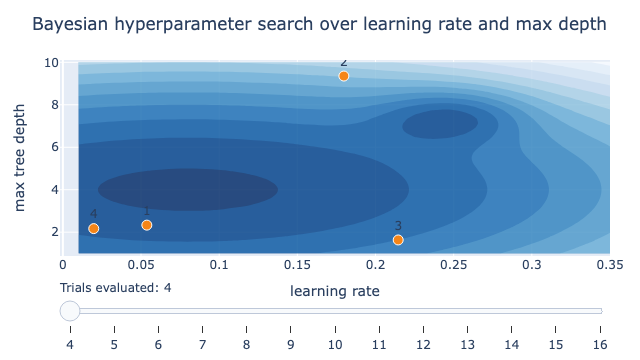

In [8]:
fig = FIGURES["chapter-bayes-boosting-fig-search-trajectory"]()
fig

**`chapter-bayes-boosting-fig-expected-improvement`**

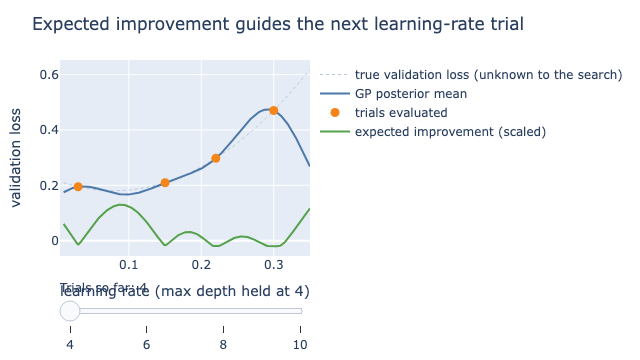

In [9]:
fig = FIGURES["chapter-bayes-boosting-fig-expected-improvement"]()
fig

**`chapter-bayes-boosting-fig-ngboost-width`**

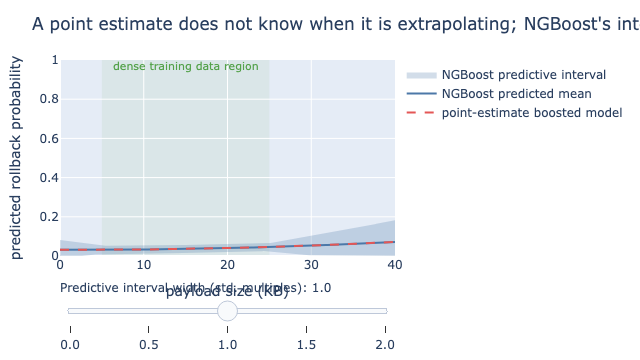

In [10]:
fig = FIGURES["chapter-bayes-boosting-fig-ngboost-width"]()
fig